# Particle Scanning & 3D Scoring Pipeline
This notebook runs slice-wise detection on tomograms, post-processes detections into object candidates, evaluates against available centers, and re-scores candidates using a lightweight 3D CNN. It concludes with optional training of a new 3D CNN scorer.

In [34]:
import sys 
sys.path.append("../src")
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import utils
import data
import torch
import postprocess 
import modules
from tqdm import tqdm
from torch.utils.data import DataLoader, random_split 
import pickle
import pytorch_lightning as pl

In [11]:
# load model
model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc_clean/fold2_ribo", "stage2/last.ckpt")
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc_clean/has_pretrain", "stage2/epoch=14-total_validate_loss=0.3876.ckpt")
model = model.eval()

Some weights of ConditionalDetrForObjectDetection were not initialized from the model checkpoint at microsoft/conditional-detr-resnet-50 and are newly initialized because the shapes did not match:
- class_labels_classifier.bias: found shape torch.Size([91]) in the checkpoint and torch.Size([1]) in the model instantiated
- class_labels_classifier.weight: found shape torch.Size([91, 256]) in the checkpoint and torch.Size([1, 256]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
/home/feity/cryoem/n

model at stage  stage 1
model with output classes 2
model receiving class weights tensor([1.0000, 0.6000])
using consistency regularization coef 0.5
incompatible parameters ['model.class_labels_classifier.weight', 'model.class_labels_classifier.bias', 'additional_input_layer.layer1.weight', 'additional_input_layer.layer1.bias', 'additional_input_layer.layer2.weight', 'additional_input_layer.layer2.bias', 'gnn.conv1.lin_l.weight', 'gnn.conv1.lin_l.bias', 'gnn.conv1.lin_r.weight', 'gnn.conv2.lin_l.weight', 'gnn.conv2.lin_l.bias', 'gnn.conv2.lin_r.weight', 'gnn.conv3.lin_l.weight', 'gnn.conv3.lin_l.bias', 'gnn.conv3.lin_r.weight', 'gnn.cls_head.0.weight', 'gnn.cls_head.0.bias', 'gnn.cls_head.2.weight', 'gnn.cls_head.2.bias', 'gnn.box_head.0.weight', 'gnn.box_head.0.bias', 'gnn.box_head.2.weight', 'gnn.box_head.2.bias', 'gnn.edge_head.0.weight', 'gnn.edge_head.0.bias', 'gnn.edge_head.2.weight', 'gnn.edge_head.2.bias', 'gnn.edge_head.4.weight', 'cri.weight']
finish loading parameters


/home/feity/cryoem/notebooks/../src/utils.py:1137: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(os.path.join(path, checkpoint), map_location="cpu")["state

incompatible parameters []
finish loading parameters


## Load Trained Detector
Load the stage-2 detector (DETR-based) from a checkpoint. Set to `eval()` for inference-only usage.

In [24]:
with open("/data/transformer_project/transforemer_model/train_data/training/newdata/24092002_ribo.pkl","rb") as f:
    d = pickle.load(f)
d["mrc_path"]

'/data/transformer_project/transforemer_model/test_data/dxd20240920/tomo2/24092002_9.62Apx.mrc'

## Inspect Annotations
Load the annotation pickle to confirm the associated tomogram path and metadata before building the dataset.

In [ ]:
# dataset from annatated tomogram
dataset = data.MrcDataset(
    "/data/transformer_project/transforemer_model/train_data/training/newdata/24092002_ribo.pkl",
    norm="hist",
    reshape=800,
    map_class={"ribosome":0 },
    gap=1,
    length_for_average=3,
    transform=data.getConstantTransform(),
    add_classname=True,
    filtermin=0
)

# dataset from plain mrc
# dataset = data.TestDatasetMrc(
#     # "/data/transformer_project/transforemer_model/train_data/sull20240716_sllt0039/tomo/sllt0039_9.62Apx.mrc",
#     # "/data/transformer_project/transforemer_model/train_data/TS_031/tomo/TS_031.mrc_10.30Apx.mrc",
#     norm="hist",
#     reshape=800,
#     # transform=data.getConstantTransform(),
#     length_for_average=3,
#     gap = 1
# )

model = model.cpu()
df, graphs = postprocess.generatedf(model, dataset, gap = 1, columns=["ribo", "None"], filter_prob=0.2, max_edges=20)

reading dataset: /data/transformer_project/transforemer_model/train_data/training/newdata/24092002_ribo.pkl
dataset map classes:  {'ribosome': 0}
dataset length: 447


100%|██████████| 447/447 [02:13<00:00,  3.34it/s]


finish dataset
build graph
prepare df


## Build Dataset & Run Inference
Create an `MrcDataset` from the annotations to produce per-slice inputs. Run the detector to generate a candidates DataFrame (`df`) and optional `graphs` for spatial postprocessing.

In [13]:
df["unlabeled"] = True 
df["label"] = "" 
df["label_id"] = -1

params= {
    "ribo":{"min_prob":0.4, "nms":0.2, "dbscan_prams":{"min_samples": 6, "eps": 0.5, "dis_penalty_coef": 2.0*(1/500), "dis_penalty_cutoff": 5}}, 
    "hsp60":{"min_prob":0.6, "nms":0.2, "max_area":0.03*0.03, "dbscan_prams":{"min_samples": 4, "eps": 0.5, "dis_penalty_coef": 2.0*(1/500), "dis_penalty_cutoff": 3, "enlarge": 0.03}}, 
}

mark_and_filter = {
    "ribo":{"max_cnt":80000, "remove_iou": 0.5, "min_samples":12, "min_length":16, "extend":0, "max_samples":30}, 
    "hsp60":{"max_cnt":5000, "remove_iou": 0.5, "min_samples":5, "min_length":10, "extend":0, "max_samples":30},
}

for i in ["ribo"]:
    subdf = postprocess.processClass(df, i, **params[i], use_myscan=False)
    # print(subdf.head())
    postprocess.markFilter(df, i, subdf, **mark_and_filter[i])

6 0.5 0.004 5
number of instances in class  705


## Post-processing Parameters
Configure thresholds for class-specific filtering and clustering. Steps include:
- Score thresholding per class (`min_prob`) and NMS (`nms`).
- Optional size constraints (e.g., `max_area`).
- Spatial clustering via DBSCAN with distance penalties to merge proximate detections.
- Marking and filtering rules to cap counts, enforce minimum samples/length, and remove overlaps.

In [14]:
df.head()

,z,x,y,w,h,ribo,None,max,largest,unlabeled,label,label_id,class_value
0,40,0.944121,0.138128,0.021497,0.023560,0.187013,0.812987,0.812987,None,True,,-1,0.187013
1,40,0.879723,0.148161,0.025730,0.024077,0.126476,0.873524,0.873524,None,True,,-1,0.126476
2,40,0.972723,0.197665,0.020536,0.021871,0.095124,0.904876,0.904876,None,True,,-1,0.095124
3,40,0.036582,0.053412,0.021997,0.021635,0.216165,0.783835,0.783835,None,True,,-1,0.216165
4,40,0.036940,0.378139,0.020837,0.021748,0.153984,0.846016,0.846016,None,True,,-1,0.153984


## Preview Candidates
Inspect the first rows of the candidates table to verify columns like slice index `z`, coordinates `(x, y, w, h)`, class labels, and scores.

/tmp/ipykernel_3401066/1095585570.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
/home/feity/cryoem/notebooks/../src/utils.py:75: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  annotated_tensor = torch.tensor(annotated_tensor, dtype=torch.uint8)


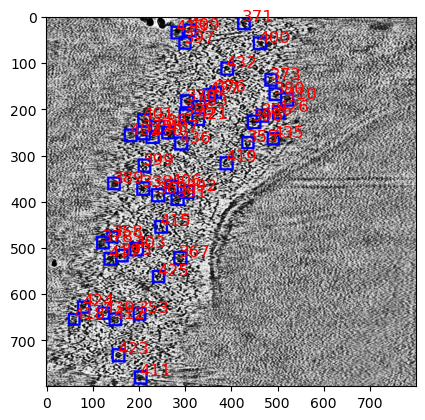

In [15]:
take = 250

# img = retdict["images"][take]
img = dataset.__getitem__(pos=take)["pixel_values"]

# subdf2 = subdf.loc[need]
# subdf = df
subdf = df[df["z"] == take] 
subdf = subdf[subdf["label_id"] != -1]

# subdf2 = df.loc[need2]

""" if use dbscan results """

# subdf2["label"] = subdf2["label"].astype("str")
# print(subdf2.head())

bboxes = subdf[["x", "y", "w", "h"]].values
bboxes = utils.convertBoxes(torch.tensor(bboxes))
bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
# bboxes, img.shape
img[0] = img[1]
img[2] = img[1]
labels = {"bboxes": bboxes, "labels": list(subdf['label_id'].astype(str))} 
utils.drawannotation(img, labels, font_size=12)
plt.show()
plt.close()


## Visualize Detections on a Slice
Select a slice `z` and overlay filtered detections as bounding boxes to sanity-check spatial coverage and class assignments.

In [18]:
with open("/data/transformer_project/transforemer_model/train_data/training/cr/temp/ribo_centers_new.pkl", "rb") as f:
    ribo_centers = pickle.load(f)
labels = ribo_centers["24092002"]

## Load Ground-Truth Centers
Load reference particle centers for the target tomogram; used to compute matching-based metrics against predictions.

In [19]:
score, predict_center, ids = postprocess.getPredictionCenters(df, "ribo", image_size=1024, top_n=20)
idx = np.argsort(-score)
score = score[idx]
predict_center = predict_center[idx]
matches, match_dists, closest = postprocess.match_and_find_closest(predict_center, labels)
t, cnt = postprocess.calculate_metrics(matches, match_dists, score, threshold=20), len(idx)
print(t)
print("final score:", t["aupr2"]*t["cnts"]/len(labels))

{'auroc': 0.8014510832939017, 'aupr': 0.795137505537384, 'aupr2': 0.7963328739491659, 'cnts': 287}
final score: 0.5890400382046664


## Compute Prediction Centers & Metrics
Aggregate per-slice detections into candidate centers, match to ground-truth, and compute metrics such as AUPR-like scores, recall at distance thresholds, and overall counts.

# 3D CNN Re-scoring
Use a lightweight 3D CNN to score cubic crops around candidate centers, improving ranking over 2D detection scores.

In [31]:
df_score = pd.DataFrame(predict_center, columns=["z", "y", "x"]) 
df_score["tomogram"] = "24092002" 
df_score["label"] = 0 
tomos = {"24092002":'/data/transformer_project/transforemer_model/test_data/dxd20240920/tomo2/24092002_9.62Apx.mrc'}
dataset_test = data.Particle3DDataset(df_score, tomo_paths=tomos, crop_size=65, norm="hist", r=0) 

## Build 3D Scoring Dataset
Create a DataFrame of candidate centers (`z, y, x`), attach tomogram identifiers, and build a `Particle3DDataset` to extract 3D crops for the scorer.

In [32]:
# Predict all instances in the validation dataset using the trained model



model = modules.ParticleID3DNet_Binary()
test_loader = DataLoader(dataset_test, batch_size=32, shuffle=False, num_workers=4)

model.load_state_dict(torch.load(f"/data/transformer_project/transforemer_model/train_data/training/results/step3res/hsp60/ribo_3d_model_fold2.pth"))   
model = model.cuda()
# val_loader.dataset.r = 0  # disable random shift for evaluation 
model.eval()
preds = []
# labels = []
with torch.no_grad():
    for batch in tqdm(test_loader):
        x, y = batch
        x = x.cuda() if next(model.parameters()).is_cuda else x
        logits = model(x)
        # prob = torch.sigmoid(logits).cpu().numpy()
        preds.append(logits.cpu().numpy())
        # labels.append(y.cpu().numpy())


all_preds = np.concatenate(preds)

/tmp/ipykernel_3401066/1194526651.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"/data/transformer_project/transforemer_model/train_d

100%|██████████| 17/17 [00:02<00:00,  6.69it/s]


## Run 3D CNN Inference
Load a trained 3D CNN (`ParticleID3DNet_Binary`), run forward passes on all crops, and collect raw logits (or sigmoid probabilities) for each candidate.

In [33]:
df_score["3DCNN"] = all_preds
# score, predict_center, ids = postprocess.getPredictionCenters(df, "ribo", image_size=1024, top_n=20)
# idx = np.argsort(-score)
# score = score[idx]
predict_center = df_score[["z", "y", "x"]].values 
score = all_preds
matches, match_dists, closest = postprocess.match_and_find_closest(predict_center, labels)
t, cnt = postprocess.calculate_metrics(matches, match_dists, score, threshold=20), len(idx)
print(t)
print("final score:", t["aupr2"]*t["cnts"]/len(labels))

{'auroc': 0.8503606200083165, 'aupr': 0.8531541227586156, 'aupr2': 0.8536770932865333, 'cnts': 287}
final score: 0.6314570251887501


## Evaluate 3D Scores
Attach 3D scores back to candidates and recompute center matching and metrics to quantify improvements.

# Train a New 3D CNN
Build a balanced training set by pairing matched positives with unmatched negatives, then train a compact 3D CNN scorer from scratch.

In [37]:
need = [] 
predict_center = df_score[["z", "y", "x"]].values 
matches, match_dists, closest = postprocess.match_and_find_closest(predict_center, labels)
matches = np.array(matches)
matched = matches[match_dists < 15] 
matched = matched[:, 1]
for j in range(predict_center.shape[0]):
    if j not in matched:
        need.append(j) 
k = [1] * len(labels) + [0] * len(need)
values = np.concatenate([labels, predict_center[need]], axis=0)
df = pd.DataFrame(values, columns=["z", "y", "x"])
df["label"] = k
df["tomogram"] = "24092002"

,z,y,x,label,tomogram
0,55.584869,995.024408,102.387730,1,24092002
1,63.459270,813.763858,65.601404,1,24092002
2,65.233981,216.902765,60.681580,1,24092002
3,68.368957,247.871757,52.378570,1,24092002
4,81.137680,295.396787,118.012890,1,24092002


## Build Training Labels
Use matching results to collect positives (within a distance threshold) and negatives (unmatched). Assemble a labeled DataFrame of candidate centers.

In [39]:
tomos = {"24092002":'/data/transformer_project/transforemer_model/test_data/dxd20240920/tomo2/24092002_9.62Apx.mrc'}
dataset = data.Particle3DDataset(df, tomo_paths=tomos, crop_size=65, norm="hist", r=0) 
train_set, val_set = random_split(dataset, [0.8, 0.2], generator=torch.Generator().manual_seed(42))
train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False, num_workers=4)

## Create Dataloaders
Split into train/validation sets and create PyTorch DataLoaders for efficient 3D crop batching.

In [40]:
model = modules.ParticleID3DNet_Binary()
trainer = pl.Trainer(max_epochs=25, accelerator="gpu", devices=[1])
trainer.fit(model, train_loader, val_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]

   | Name      | Type              | Params | Mode 
---------------------------------------------------------
0  | conv1     | Conv3d            | 2.0 K  | train
1  | bn1       | BatchNorm3d       | 32     | train
2  | conv1_1   | Conv3d            | 32.0 K | train
3  | conv2     | Conv3d            | 64.0 K | train
4  | bn2       | BatchNorm3d       | 64     | train
5  | conv2_1   | Conv3d            | 128 K  | train
6  | conv3     | Conv3d            | 256 K  | tra

Sanity Checking DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 12.32it/s]val_aupr 0.517892499472451 val_auroc 0.3384615384615384


/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/pytorch_lightning/loops/fit_loop.py:298: The number of training batches (16) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 0: 100%|██████████| 16/16 [00:05<00:00,  3.19it/s, v_num=61]

`Trainer.fit` stopped: `max_epochs=1` reached.


Epoch 0: 100%|██████████| 16/16 [00:05<00:00,  2.97it/s, v_num=61]


## Train 3D CNN Scorer
Initialize the 3D CNN module and train with PyTorch Lightning. Adjust `max_epochs`, GPU device, and batch size as needed for your environment.